In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [17]:
df =pd.read_csv('Powei.csv')
x = df.iloc[:, : -1].values
y = df.iloc[:, -1].values

In [68]:
print(x)

[['Nigeria' 40.0 89920.0]
 ['Ghana' 55.0 81685.0]
 ['Nigeria' 46.0 49222.0]
 ['Togo' 49.0 nan]
 ['Nigeria' 22.0 66345.0]
 ['Togo' 36.0 57818.0]
 ['Nigeria' 43.0 63237.0]
 ['Togo' 42.0 97993.0]
 ['Ghana' 24.0 77470.0]
 ['Nigeria' 20.0 nan]
 ['Togo' 53.0 25949.0]
 ['Ghana' 44.0 44563.0]
 ['Nigeria' 46.0 131754.0]
 ['Nigeria' 46.0 95070.0]
 ['Ghana' 21.0 119418.0]
 ['Ghana' 19.0 65992.0]
 ['Nigeria' 42.0 35215.0]
 ['Nigeria' 40.0 103601.0]
 ['Togo' 20.0 125430.0]
 ['Togo' 20.0 134095.0]
 ['Nigeria' 23.0 88706.0]
 ['Ghana' 32.0 84679.0]
 ['Ghana' 47.0 25446.0]
 ['Ghana' 58.0 74158.0]
 ['Togo' 42.0 115252.0]
 ['Togo' 27.0 65943.0]
 ['Nigeria' 25.0 47500.0]
 ['Nigeria' 36.0 71984.0]
 ['Nigeria' 52.0 108604.0]
 ['Nigeria' nan 36509.0]
 ['Togo' 19.0 100704.0]
 ['Nigeria' 22.0 77175.0]
 ['Nigeria' 33.0 71772.0]
 ['Nigeria' 26.0 68140.0]
 ['Nigeria' 46.0 62975.0]
 ['Nigeria' 61.0 62169.0]
 ['Togo' 62.0 91813.0]
 ['Nigeria' 18.0 64179.0]
 ['Ghana' nan 125783.0]
 ['Ghana' 54.0 97001.0]
 ['Ghana' 2

In [69]:
print(y)

<StringArray>
[ 'No',  'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',  'No',
 ...
  'No', 'Yes',  'No',  'No', 'Yes',  'No', 'Yes',  'No',  'No', 'Yes']
Length: 250, dtype: str


In [15]:
df['Salary'] = np.log(df['Salary'])

In [17]:
df['Age'] = np.log(df['Age'])

<Axes: xlabel='Age', ylabel='Salary'>

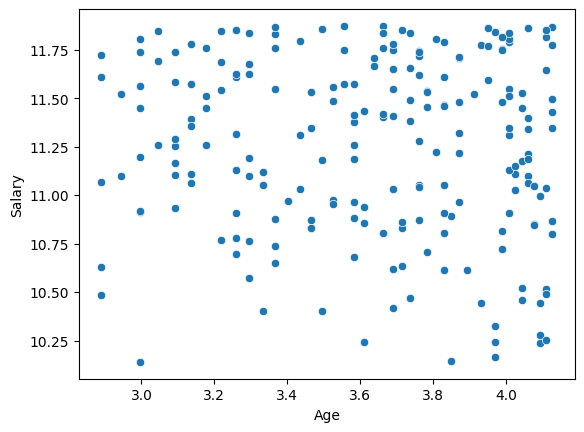

In [21]:
sns.scatterplot(x='Age', y='Salary', data=df)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    250 non-null    str    
 1   Age        232 non-null    float64
 2   Salary     230 non-null    float64
 3   Purchased  250 non-null    str    
dtypes: float64(2), str(2)
memory usage: 7.9 KB


In [4]:
df.columns

Index(['Country', 'Age', 'Salary', 'Purchased'], dtype='str')

In [5]:
df['Country'].unique()

<StringArray>
['Nigeria', 'Ghana', 'Togo']
Length: 3, dtype: str

Fixing Mixing Data

In [18]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(x[:, 1:3])
x[:, 1:3] = imputer.transform(x[:, 1:3])

In [72]:
print(x)

[['Nigeria' 40.0 89920.0]
 ['Ghana' 55.0 81685.0]
 ['Nigeria' 46.0 49222.0]
 ['Togo' 49.0 85544.34347826087]
 ['Nigeria' 22.0 66345.0]
 ['Togo' 36.0 57818.0]
 ['Nigeria' 43.0 63237.0]
 ['Togo' 42.0 97993.0]
 ['Ghana' 24.0 77470.0]
 ['Nigeria' 20.0 85544.34347826087]
 ['Togo' 53.0 25949.0]
 ['Ghana' 44.0 44563.0]
 ['Nigeria' 46.0 131754.0]
 ['Nigeria' 46.0 95070.0]
 ['Ghana' 21.0 119418.0]
 ['Ghana' 19.0 65992.0]
 ['Nigeria' 42.0 35215.0]
 ['Nigeria' 40.0 103601.0]
 ['Togo' 20.0 125430.0]
 ['Togo' 20.0 134095.0]
 ['Nigeria' 23.0 88706.0]
 ['Ghana' 32.0 84679.0]
 ['Ghana' 47.0 25446.0]
 ['Ghana' 58.0 74158.0]
 ['Togo' 42.0 115252.0]
 ['Togo' 27.0 65943.0]
 ['Nigeria' 25.0 47500.0]
 ['Nigeria' 36.0 71984.0]
 ['Nigeria' 52.0 108604.0]
 ['Nigeria' 39.62068965517241 36509.0]
 ['Togo' 19.0 100704.0]
 ['Nigeria' 22.0 77175.0]
 ['Nigeria' 33.0 71772.0]
 ['Nigeria' 26.0 68140.0]
 ['Nigeria' 46.0 62975.0]
 ['Nigeria' 61.0 62169.0]
 ['Togo' 62.0 91813.0]
 ['Nigeria' 18.0 64179.0]
 ['Ghana' 39.6206

Encoding Category Data 

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder  
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [30]:
print(x)

[[0.0 1.0 0.0 40.0 89920.0]
 [1.0 0.0 0.0 55.0 81685.0]
 [0.0 1.0 0.0 46.0 49222.0]
 ...
 [0.0 1.0 0.0 62.0 130061.0]
 [1.0 0.0 0.0 27.0 112038.0]
 [0.0 1.0 0.0 23.0 66804.0]]


In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [32]:
print(y)

[0 0 1 1 1 1 1 1 1 0 1 0 1 1 1 0 0 0 1 1 1 0 1 1 1 1 1 0 1 0 0 1 0 0 1 0 1
 0 0 0 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1
 1 0 1 0 1 0 1 1 0 0 1 0 0 1 0 0 0 1 1 1 0 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 0
 1 1 0 0 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1 0 1 1 0 1 0
 0 1 0 1 0 0 1 1 1 1 0 0 0 1 0 0 1 1 0 1 1 1 1 1 0 0 0 1 1 1 0 0 0 0 1 0 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1
 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1]


Splitting t he data into Training and Test sets

In [22]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [33]:
print(x_train)

[[0.0 0.0 1.0 -1.5287749509982926 -0.03952671989528364]
 [0.0 1.0 0.0 1.3213258611312688 -1.5194881780795653]
 [1.0 0.0 0.0 -0.6814476825273419 -0.7671527539396017]
 [0.0 1.0 0.0 -0.5273881791689873 -1.6486251723170826]
 [0.0 1.0 0.0 0.08884983426443145 -1.1107532235632824]
 [1.0 0.0 0.0 0.6280580960186728 -0.13722365861847408]
 [0.0 1.0 0.0 0.47399859266031813 0.7046602095236721]
 [0.0 0.0 1.0 -1.5287749509982926 1.1807324121604894]
 [0.0 1.0 0.0 -0.8355071858856966 1.707437575106023]
 [1.0 0.0 0.0 -1.60580470267747 -0.6377098203648718]
 [0.0 1.0 0.0 0.24290933762278613 1.1847402174779769]
 [1.0 0.0 0.0 -0.8355071858856966 1.2614698032509437]
 [0.0 0.0 1.0 0.1658795859436088 0.34132665264976675]
 [0.0 0.0 1.0 1.552415116168801 -1.6058854469084562]
 [1.0 0.0 0.0 -1.6828344543566474 -1.5642165091800748]
 [1.0 0.0 0.0 1.4753853644896235 -0.7389757409823041]
 [0.0 1.0 0.0 -1.0665964409232287 -0.5719940507315652]
 [1.0 0.0 0.0 -1.2206559442815832 0.21885913596348827]
 [0.0 0.0 1.0 -0.29629

In [34]:
print(x_test)

[[1.0 0.0 0.0 -0.8355071858856966 -1.3632755524987166]
 [0.0 1.0 0.0 0.24290933762278613 -0.7465936304789025]
 [1.0 0.0 0.0 -0.912536937564874 -0.7282372702461353]
 [0.0 1.0 0.0 -0.912536937564874 -0.592614362059707]
 [0.0 0.0 1.0 -1.1436261926024058 0.9844111394710442]
 [0.0 0.0 1.0 0.6280580960186728 -0.8867138469223588]
 [0.0 1.0 0.0 -0.8355071858856966 -1.2466514771532022]
 [1.0 0.0 0.0 1.167266357772914 1.3697111407568276]
 [0.0 0.0 1.0 0.08884983426443145 -1.3856397180489712]
 [0.0 1.0 0.0 -1.0665964409232287 0.7167448133435772]
 [0.0 1.0 0.0 1.167266357772914 0.4019332353516198]
 [0.0 1.0 0.0 -1.374715447639938 -0.03952671989528364]
 [0.0 0.0 1.0 -1.2206559442815832 -0.03952671989528364]
 [0.0 0.0 1.0 0.8591473510562049 1.3124698907643153]
 [0.0 1.0 0.0 1.552415116168801 -1.7682168592335608]
 [1.0 0.0 0.0 -1.2976856959607606 -0.7100032857482532]
 [0.0 0.0 1.0 1.6294448678479783 -1.790305679380324]
 [1.0 0.0 0.0 -0.06520966909392321 1.5774745446580312]
 [1.0 0.0 0.0 0.93617710273

In [35]:
print(y_train)

[0 0 0 0 0 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 1
 0 1 1 1 1 0 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 0
 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 1 1 0 1 1 1 1 1 0
 1 0 1 0 1 1 1 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 1 1 1 1 1 1 0 0 0
 1 1 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 0 0 0 1 1 0
 0 0 0 1 1 0 1 0 1 0 0 1 0 1 0]


In [36]:
print(y_test)

[0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 0 0 1 1 0 1 1 0 0 1 1 0 0 1 1 0 0 0 1 0
 1 1 1 0 1 0 1 0 1 0 1 1 0]


Feature Scaling

In [46]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train[:, 1:3] = sc.fit_transform(x_train[:, 1:3])
x_test[:, 1:3] = sc.transform(x_test[:, 1:3])



In [47]:
print(x_test)

[[1.0 -0.8336157713462997 -0.5619514869490158 -0.8355071858856973
  -1.3632755524987168]
 [0.0 1.1995934270593096 -0.5619514869490158 0.24290933762278502
  -0.7465936304789028]
 [1.0 -0.8336157713462997 -0.5619514869490158 -0.9125369375648745
  -0.7282372702461356]
 [0.0 1.1995934270593096 -0.5619514869490158 -0.9125369375648745
  -0.5926143620597073]
 [0.0 -0.8336157713462997 1.7795130420052168 -1.1436261926024065
  0.9844111394710439]
 [0.0 -0.8336157713462997 1.7795130420052168 0.6280580960186715
  -0.8867138469223591]
 [0.0 1.1995934270593096 -0.5619514869490158 -0.8355071858856973
  -1.2466514771532025]
 [1.0 -0.8336157713462997 -0.5619514869490158 1.1672663577729125
  1.3697111407568274]
 [0.0 -0.8336157713462997 1.7795130420052168 0.08884983426443041
  -1.3856397180489715]
 [0.0 1.1995934270593096 -0.5619514869490158 -1.0665964409232294
  0.7167448133435769]
 [0.0 1.1995934270593096 -0.5619514869490158 1.1672663577729125
  0.40193323535161946]
 [0.0 1.1995934270593096 -0.5619514

In [48]:
print(x_train)

[[0.0 -0.8336157713462997 1.7795130420052168 -1.528774950998293
  -0.03952671989528395]
 [0.0 1.1995934270593096 -0.5619514869490158 1.321325861131267
  -1.5194881780795655]
 [1.0 -0.8336157713462997 -0.5619514869490158 -0.6814476825273426
  -0.767152753939602]
 [0.0 1.1995934270593096 -0.5619514869490158 -0.5273881791689881
  -1.6486251723170828]
 [0.0 1.1995934270593096 -0.5619514869490158 0.08884983426443041
  -1.1107532235632827]
 [1.0 -0.8336157713462997 -0.5619514869490158 0.6280580960186715
  -0.13722365861847438]
 [0.0 1.1995934270593096 -0.5619514869490158 0.4739985926603169
  0.7046602095236718]
 [0.0 -0.8336157713462997 1.7795130420052168 -1.528774950998293
  1.1807324121604892]
 [0.0 1.1995934270593096 -0.5619514869490158 -0.8355071858856973
  1.7074375751060227]
 [1.0 -0.8336157713462997 -0.5619514869490158 -1.6058047026774704
  -0.6377098203648721]
 [0.0 1.1995934270593096 -0.5619514869490158 0.24290933762278502
  1.1847402174779766]
 [1.0 -0.8336157713462997 -0.561951486

Regression

In [49]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
y_pred = model.predict(x_test)

In [51]:
print(y_pred)

[0.48487834 0.48306678 0.50053596 0.49474466 0.51020155 0.45335705
 0.47863458 0.53607953 0.44521342 0.52699543 0.50401051 0.51112089
 0.48635032 0.50412889 0.44965767 0.50364049 0.4248951  0.54957235
 0.54529193 0.47863495 0.45773819 0.47425546 0.48395632 0.47090985
 0.52067614 0.49887104 0.513191   0.54911574 0.49542489 0.49769031
 0.5488673  0.48997003 0.53280338 0.48927984 0.5041565  0.46389856
 0.50572008 0.45974022 0.46300299 0.50058842 0.46123712 0.53197194
 0.49863208 0.52956389 0.44722083 0.50586762 0.51062208 0.51950431
 0.44030927 0.46872648]


In [52]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test, y_pred))

0.5012081593485066


In [53]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_test, y_pred))

0.25216175820662895


In [55]:
from sklearn.metrics import r2_score
print(r2_score(y_test, y_pred))

-0.015143954132966542
